# Solar Panel Segmentation Pipeline (SAM 3)

End-to-end pipeline: load test images, run **Ultralytics SAM 3** (`sam3.pt`) with a text prompt, track experiments with MLflow, evaluate on labeled data, and visualize results.

## Download SAM 3 weights (`sam3.pt`)

Unlike YOLO models, **Ultralytics does not auto-download** SAM 3 weights. You need the checkpoint file **`sam3.pt`** (~3.5 GB) from Meta on Hugging Face.

### Prerequisites (one-time)

| Step | Action |
|------|--------|
| 1 | Create a free account at [huggingface.co/join](https://huggingface.co/join) |
| 2 | Open [facebook/sam3](https://huggingface.co/facebook/sam3) and click **Request access** (approval is usually quick) |
| 3 | Create a read token at [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) — **Read** access is enough |
| 4 | Download `sam3.pt` using **one** of the methods below |
| 5 | Save to the project folder: `gd a revelia/sam3.pt` (same folder as this notebook) |

### Download methods

**Method A — Notebook cell** (recommended): run the **Download sam3.pt** cell below. It prompts for Hugging Face login if needed and skips download if the file already exists.

**Method B — Browser:** on [facebook/sam3](https://huggingface.co/facebook/sam3), open **Files and versions**, download **`sam3.pt`**, and move it to `gd a revelia/sam3.pt`.

**Method C — Terminal** (PowerShell or CMD):

```bash
pip install huggingface_hub
huggingface-cli login
cd "gd a revelia"
huggingface-cli download facebook/sam3 sam3.pt --local-dir . --local-dir-use-symlinks False
```

**Method D — Direct URL** (after browser login):  
`https://huggingface.co/facebook/sam3/resolve/main/sam3.pt`

### Verify the download

- The download cell prints `sam3.pt already present` and size ~3.4 GB, **or**
- **Stage 1** prints `Model exists: True` for `sam3.pt`.

Docs: [Ultralytics SAM 3](https://docs.ultralytics.com/models/sam-3/) · [Hugging Face facebook/sam3](https://huggingface.co/facebook/sam3)


## Pipeline Architecture

| Stage | Notebook section | Purpose |
|-------|------------------|---------|
| 1 | Data Input | Discover inference and evaluation images |
| 2 | Load Model | Load `sam3.pt` via `SAM3SemanticPredictor` |
| 3 | MLflow | Track parameters, metrics, and artifacts |
| 4 | Inference Layer | Text-prompt segmentation per image |
| 5 | Save Results | Precision, recall, F1, area table, CSV/JSON |
| 6 | Present Results | Overlays, plots, and summary |

## How to run

1. Working directory: `gd a revelia` (`dados_teste/`, `sam3.pt`, `dataset_yolo/`).
2. Download `sam3.pt` (section above or **Download sam3.pt** cell).
3. **GPU (optional):** `USE_GPU = True` in Setup; install CUDA PyTorch if you see `torch+cpu`.
4. **Kernel → Restart**, then **Run All**.
5. Details: `README_sam3_pipeline.md`


### Download `sam3.pt` (run once)

**Before running:** approved access at [facebook/sam3](https://huggingface.co/facebook/sam3) and a token at [settings/tokens](https://huggingface.co/settings/tokens).

1. Set the working directory to `gd a revelia` (where `dados_teste/` and this notebook live).
2. Run the cell — if prompted, paste your Hugging Face token.
3. If `sam3.pt` already exists, the cell only confirms the path and size (~3.5 GB).

Dependency: `pip install huggingface_hub` (listed in Setup).


In [1]:
from pathlib import Path

from huggingface_hub import get_token, hf_hub_download, login

# Project folder (this notebook and dados_teste/ should live here)
PROJECT_DIR = Path.cwd()
weights = PROJECT_DIR / "sam3.pt"

MIN_SIZE_GB = 3.0  # full file is ~3.45 GB

if weights.is_file() and weights.stat().st_size / 1e9 >= MIN_SIZE_GB:
    print("sam3.pt already present:", weights.resolve())
    print("Size (GB):", round(weights.stat().st_size / 1e9, 2))
else:
    if weights.is_file():
        print("Warning: sam3.pt looks incomplete — re-downloading...")
    if not get_token():
        print("Steps before download:")
        print("  1) Request access: https://huggingface.co/facebook/sam3")
        print("  2) Create token (Read): https://huggingface.co/settings/tokens")
        print("  3) Paste the token when prompted below")
        login()
    if not get_token():
        raise RuntimeError(
            "Hugging Face token required. Create one at https://huggingface.co/settings/tokens "
            "and approve access at https://huggingface.co/facebook/sam3"
        )
    print("Downloading sam3.pt (~3.5 GB) — may take several minutes...")
    hf_hub_download(
        repo_id="facebook/sam3",
        filename="sam3.pt",
        local_dir=PROJECT_DIR,
        local_dir_use_symlinks=False,
    )
    if not weights.is_file():
        raise FileNotFoundError(f"Download failed — expected at {weights}")
    print("Saved to:", weights.resolve())
    print("Size (GB):", round(weights.stat().st_size / 1e9, 2))


sam3.pt already present: C:\Users\danie\gd a revelia\sam3.pt
Size (GB): 3.45


## Setup

1. **GPU:** `USE_GPU = True` in CONFIG.
2. If you see `torch+cpu`, run the **Install CUDA PyTorch** cell, then **Kernel → Restart**, and run **Setup** again.
3. Success looks like: `Inference device: GPU 0 — NVIDIA GeForce RTX 4060 ...`


In [2]:
# Run ONCE if Setup shows torch+cpu. Then: Kernel -> Restart -> Run Setup again.
import subprocess
import sys

print("Python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "torch", "torchvision", "-y"])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "torch", "torchvision",
    "--index-url", "https://download.pytorch.org/whl/cu124",
])
print("Done. Kernel -> Restart, then re-run Setup.")


Python: C:\Users\danie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
Done. Kernel -> Restart, then re-run Setup.


In [3]:
# %pip install -U "ultralytics>=8.3.237" opencv-python mlflow scikit-learn matplotlib pandas tqdm pillow huggingface_hub
# GPU: uncomment ONE line for your Python kernel, then Restart kernel:
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124
# If CLIP error: pip uninstall clip -y && pip install git+https://github.com/ultralytics/CLIP.git

import json
import os
import sys
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from tqdm import tqdm

import ultralytics

warnings.filterwarnings("ignore")


def configure_compute(use_gpu=True, gpu_index=0):
    """Pick CPU or NVIDIA GPU for SAM 3 inference."""
    if use_gpu and torch.cuda.is_available():
        if gpu_index >= torch.cuda.device_count():
            raise ValueError(f"GPU index {gpu_index} invalid; found {torch.cuda.device_count()} device(s)")
        name = torch.cuda.get_device_name(gpu_index)
        vram_gb = torch.cuda.get_device_properties(gpu_index).total_memory / (1024 ** 3)
        return {
            "DEVICE": "cuda",
            "ULTRALYTICS_DEVICE": gpu_index,
            "USE_HALF": True,
            "GPU_NAME": name,
            "GPU_INDEX": gpu_index,
        }
    if use_gpu:
        print("=" * 60)
        print("USE_GPU=True but PyTorch has no CUDA (likely torch+cpu build).")
        print("Python:", sys.executable)
        print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available())
        print("Fix — run in a notebook cell, then Kernel -> Restart:")
        print('  %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124')
        print("=" * 60)
    return {
        "DEVICE": "cpu",
        "ULTRALYTICS_DEVICE": "cpu",
        "USE_HALF": False,
        "GPU_NAME": None,
        "GPU_INDEX": None,
    }


CONFIG = {
    "MODEL_PATH": "sam3.pt",
    "MODEL_FALLBACKS": ["models/sam3.pt", "weights/sam3.pt"],
    "TEXT_PROMPT": "solar panel",
    "TEXT_PROMPTS": ["solar panel"],
    "CONF_THRESHOLD": 0.25,
    "IOU_THRESHOLD": 0.5,
    "IMGSZ": 1008,
    "INFERENCE_DIR": "dados_teste",
    "DATASET_DIR": "dataset_yolo",
    "OUTPUT_DIR": "results/sam3_pipeline",
    "MLFLOW_TRACKING_URI": "./mlruns",
    "MLFLOW_EXPERIMENT": "solar-panel-sam3",
    "MASK_THRESHOLD": 0.5,
    "RUN_NAME": "sam3_inference_eval",
    "METERS_PER_PIXEL": 0.3,
    "POWER_KW_PER_SQM": 0.15,
    "NUM_IMAGES_DEBUG": None,
    "USE_GPU": True,
    "GPU_INDEX": 0,
}

CONFIG.update(configure_compute(use_gpu=CONFIG["USE_GPU"], gpu_index=CONFIG["GPU_INDEX"]))

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
print("Setup complete. Output dir:", CONFIG["OUTPUT_DIR"])
print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
if CONFIG["DEVICE"] == "cuda":
    print(f"Inference device: GPU {CONFIG['GPU_INDEX']} — {CONFIG['GPU_NAME']}")
    print(f"FP16 (half): {CONFIG['USE_HALF']} | imgsz: {CONFIG['IMGSZ']}")
    print("Tip: RTX 4060 (8 GB) — if CUDA OOM, set IMGSZ=640 or NUM_IMAGES_DEBUG=2")
else:
    print("Inference device: CPU (slower). Enable GPU: USE_GPU=True + CUDA PyTorch.")
if CONFIG["USE_GPU"] and CONFIG["DEVICE"] == "cpu":
    if "+cpu" in torch.__version__.lower():
        print("\n>>> PyTorch in memory is still CPU. Kernel -> Restart -> Run Setup again.")
    else:
        print("\n>>> CUDA not visible. Kernel:", sys.executable)



Setup complete. Output dir: results/sam3_pipeline
Ultralytics: 8.4.60
PyTorch: 2.6.0+cu124
Inference device: GPU 0 — NVIDIA GeForce RTX 4060 Laptop GPU
FP16 (half): True | imgsz: 1008
Tip: RTX 4060 (8 GB) — if CUDA OOM, set IMGSZ=640 or NUM_IMAGES_DEBUG=2


---
## Stage 1 — Data Input

Two image sources:

- **Inference set:** all PNGs in `dados_teste/` (batch scoring).
- **Evaluation set:** images in `dataset_yolo` that have a matching YOLO label file (used for precision, recall, and F1).


In [4]:
def resolve_model_path():
    candidates = [Path(CONFIG["MODEL_PATH"])] + [Path(p) for p in CONFIG["MODEL_FALLBACKS"]]
    for p in candidates:
        if p.is_file():
            return str(p.resolve())
    return CONFIG["MODEL_PATH"]


def list_inference_images(directory):
    root = Path(directory)
    if not root.exists():
        raise FileNotFoundError(f"Inference directory not found: {root}")
    images = sorted(root.glob("*.png"))
    n = CONFIG["NUM_IMAGES_DEBUG"]
    return images[:n] if n else images


def list_labeled_eval_images(dataset_dir):
    root = Path(dataset_dir)
    eval_items = []
    for split in ("train", "val", "test"):
        img_dir = root / "images" / split
        label_dir = root / "labels" / split
        if not label_dir.exists():
            continue
        for label_path in sorted(label_dir.glob("*.txt")):
            stem = label_path.stem
            for ext in (".png", ".jpg", ".jpeg"):
                img_path = img_dir / f"{stem}{ext}"
                if img_path.exists():
                    eval_items.append({
                        "path": img_path,
                        "split": split,
                        "label_path": label_path,
                        "stem": stem,
                    })
                    break
    return eval_items


inference_images = list_inference_images(CONFIG["INFERENCE_DIR"])
eval_items = list_labeled_eval_images(CONFIG["DATASET_DIR"])
model_path_resolved = resolve_model_path()

print(f"Inference images: {len(inference_images)}")
print(f"Labeled eval images: {len(eval_items)}")
print(f"Model path (resolved): {model_path_resolved}")
print(f"Model exists: {Path(model_path_resolved).exists()}")
if inference_images:
    print("Sample inference:", inference_images[0].name)
if eval_items:
    print("Sample eval:", eval_items[0]["path"].name, f"({eval_items[0]['split']})")


Inference images: 52
Labeled eval images: 15
Model path (resolved): C:\Users\danie\gd a revelia\sam3.pt
Model exists: True
Sample inference: 1004739 (1).png
Sample eval: 1036553.png (train)


---
## Stage 2 — Load Trained Model

Load **`sam3.pt`** with Ultralytics `SAM3SemanticPredictor` and verify a probe inference on one image.


In [5]:
from ultralytics.models.sam import SAM3SemanticPredictor

SAM3_AVAILABLE = False
predictor = None
loaded_model_path = model_path_resolved
sam3_error = None

if not Path(model_path_resolved).is_file():
    sam3_error = FileNotFoundError(f"Missing weights: {model_path_resolved}")
    print(sam3_error)
else:
    try:
        device = CONFIG["ULTRALYTICS_DEVICE"]
        overrides = dict(
            conf=CONFIG["CONF_THRESHOLD"],
            iou=CONFIG["IOU_THRESHOLD"],
            task="segment",
            mode="predict",
            model=model_path_resolved,
            imgsz=CONFIG["IMGSZ"],
            device=device,
            half=CONFIG["USE_HALF"],
            save=False,
            verbose=False,
        )
        predictor = SAM3SemanticPredictor(overrides=overrides)
        predictor.setup_model()
        SAM3_AVAILABLE = True
        print(f"Model loaded: {loaded_model_path}")
        print(f"Device: {predictor.device}")
        # Encode text once (do not reset_prompts after — it clears language_features)
        text_prompts = list(CONFIG["TEXT_PROMPTS"])
        predictor.model.set_classes(text=text_prompts)
        probe_path = str(eval_items[0]["path"] if eval_items else inference_images[0])
        predictor.set_image(probe_path)
        probe = predictor(text=text_prompts)
        predictor.reset_image()
        n_probe = len(probe[0].masks) if probe[0].masks is not None else 0
        print(f"Probe OK on {Path(probe_path).name}: {n_probe} mask(s) for prompt {text_prompts}")
    except Exception as e:
        sam3_error = e
        SAM3_AVAILABLE = False
        print(f"Failed to load SAM 3: {type(e).__name__}: {e}")
        if "clip" in str(e).lower() or "SimpleTokenizer" in str(e):
            print("Fix CLIP: pip uninstall clip -y")
            print("      pip install git+https://github.com/ultralytics/CLIP.git")




Ultralytics 8.4.60  Python-3.13.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model loaded: C:\Users\danie\gd a revelia\sam3.pt
Device: cuda:0
Probe OK on 1036553.png: 19 mask(s) for prompt ['solar panel']


---
## Stage 3 — MLflow Tracking

Start an MLflow run and log configuration before inference. Metrics and artifacts are logged after Stage 5.


In [6]:
mlflow.set_tracking_uri(CONFIG["MLFLOW_TRACKING_URI"])
mlflow.set_experiment(CONFIG["MLFLOW_EXPERIMENT"])

if mlflow.active_run() is not None:
    print(f"Ending previous active run: {mlflow.active_run().info.run_id}")
    mlflow.end_run()

mlflow_run = mlflow.start_run(run_name=CONFIG["RUN_NAME"])

mlflow.log_params({
    "model_path": loaded_model_path,
    "backend": "ultralytics_sam3",
    "text_prompt": CONFIG["TEXT_PROMPT"],
    "conf_threshold": CONFIG["CONF_THRESHOLD"],
    "iou_threshold": CONFIG["IOU_THRESHOLD"],
    "imgsz": CONFIG["IMGSZ"],
    "device": CONFIG["DEVICE"],
    "ultralytics_device": str(CONFIG["ULTRALYTICS_DEVICE"]),
    "use_half": CONFIG["USE_HALF"],
    "gpu_name": CONFIG.get("GPU_NAME") or "none",
    "sam3_available": SAM3_AVAILABLE,
    "n_inference_images": len(inference_images),
    "n_eval_images": len(eval_items),
    "inference_dir": CONFIG["INFERENCE_DIR"],
    "dataset_dir": CONFIG["DATASET_DIR"],
})

print(f"MLflow run started: {mlflow_run.info.run_id}")
print(f"Tracking URI: {CONFIG['MLFLOW_TRACKING_URI']}")



MLflow run started: 0e7e755864af456da0e87a57ba93a79b
Tracking URI: ./mlruns


---
## Stage 4 — Inference Layer

Modular functions for SAM 3 text-prompt segmentation. The same layer runs on the full inference set and on the labeled evaluation subset.


In [7]:
def ensure_text_embeddings(predictor, text_prompts):
    """Encode text prompt into model.text_embeddings (required for SAM 3 PCS)."""
    text_prompts = list(text_prompts)
    predictor.model.set_classes(text=text_prompts)
    te = getattr(predictor.model, "text_embeddings", None) or {}
    if "language_features" not in te:
        raise KeyError(
            "language_features missing after set_classes. "
            "Re-run Stage 2 or fix CLIP: pip install git+https://github.com/ultralytics/CLIP.git"
        )
    return text_prompts


SAM3_TEXT_PROMPTS = list(CONFIG["TEXT_PROMPTS"])


def masks_from_result(result, h, w):
    combined = np.zeros((h, w), dtype=np.uint8)
    if result.masks is None or result.masks.data is None:
        return combined, 0
    data = result.masks.data
    for i in range(data.shape[0]):
        m = (data[i].cpu().numpy() > CONFIG["MASK_THRESHOLD"]).astype(np.uint8)
        if m.shape != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        combined = np.maximum(combined, m)
    return combined, int(data.shape[0])


def predict_image_sam3(predictor, image_path, text_prompts=None):
    text_prompts = list(text_prompts or SAM3_TEXT_PROMPTS)
    predictor.reset_image()
    # Do NOT call reset_prompts() — it sets text_embeddings={} and causes KeyError
    predictor.set_image(str(image_path))
    ensure_text_embeddings(predictor, text_prompts)
    results = predictor(text=text_prompts)
    return results[0]


def process_single_image(predictor, image_path):
    result = predict_image_sam3(predictor, image_path)
    img = cv2.imread(str(image_path))
    h, w = img.shape[:2]
    pred_mask, num_segments = masks_from_result(result, h, w)

    total_area_pixels = int(pred_mask.sum())
    if result.boxes is not None and len(result.boxes) > 0:
        confidences = result.boxes.conf.cpu().numpy()
        avg_conf = float(np.mean(confidences))
        max_conf = float(np.max(confidences))
        min_conf = float(np.min(confidences))
    else:
        avg_conf = max_conf = min_conf = 0.0

    total_pixels = h * w
    coverage = (total_area_pixels / total_pixels * 100) if total_pixels > 0 else 0.0

    return {
        "image": image_path.name,
        "path": str(image_path),
        "num_segments": num_segments,
        "area_pixels": total_area_pixels,
        "coverage_pct": coverage,
        "conf_mean": avg_conf,
        "conf_max": max_conf,
        "conf_min": min_conf,
        "result": result,
        "masks": result.masks,
        "pred_mask": pred_mask,
        "height": h,
        "width": w,
    }


def run_inference_on_images(predictor, image_paths, desc="Inference"):
    if not SAM3_AVAILABLE:
        raise RuntimeError(f"SAM 3 not loaded: {sam3_error}")
    ensure_text_embeddings(predictor, SAM3_TEXT_PROMPTS)
    results = []
    for img_path in tqdm(image_paths, desc=desc):
        try:
            results.append(process_single_image(predictor, img_path))
        except Exception as ex:
            print(f"Warning: {img_path.name} failed: {ex}")
            img = cv2.imread(str(img_path))
            h, w = (img.shape[:2] if img is not None else (0, 0))
            results.append({
                "image": img_path.name,
                "path": str(img_path),
                "num_segments": 0,
                "area_pixels": 0,
                "coverage_pct": 0.0,
                "conf_mean": 0.0,
                "conf_max": 0.0,
                "conf_min": 0.0,
                "result": None,
                "masks": None,
                "pred_mask": np.zeros((h, w), dtype=np.uint8),
                "height": h,
                "width": w,
            })
    return results


if SAM3_AVAILABLE:
    inference_results = run_inference_on_images(
        predictor, inference_images, desc="Inference (dados_teste)"
    )
    eval_paths = [item["path"] for item in eval_items]
    eval_inference_results = run_inference_on_images(
        predictor, eval_paths, desc="Inference (labeled eval)"
    )
    print(f"Done: {len(inference_results)} inference + {len(eval_inference_results)} eval images.")
else:
    inference_results = []
    eval_inference_results = []
    print("Skipping inference — SAM 3 not available.")



Inference (labeled eval): 100%|██████████| 15/15 [00:09<00:00,  1.64it/s]

Done: 52 inference + 15 eval images.


---
## Stage 5 — Save Results

**Metrics** (labeled subset only): pixel-level binary segmentation — solar panel vs background. Ground truth masks are rasterized from YOLO bounding-box labels.

**Exports:** CSV/JSON under `results/sam3_pipeline/` and MLflow artifacts.


In [8]:
def yolo_boxes_to_mask(label_path, width, height):
    mask = np.zeros((height, width), dtype=np.uint8)
    lines = Path(label_path).read_text(encoding="utf-8").strip().splitlines()
    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue
        _, cx, cy, bw, bh = map(float, parts[:5])
        x1 = int((cx - bw / 2) * width)
        y1 = int((cy - bh / 2) * height)
        x2 = int((cx + bw / 2) * width)
        y2 = int((cy + bh / 2) * height)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(width, x2), min(height, y2)
        if x2 > x1 and y2 > y1:
            mask[y1:y2, x1:x2] = 1
    return mask


def mask_iou(gt, pred):
    inter = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    return float(inter / union) if union > 0 else 0.0


per_image_rows = []
y_true_all, y_pred_all = [], []

if SAM3_AVAILABLE and eval_items:
    for item, pred_row in zip(eval_items, eval_inference_results):
        h, w = pred_row["height"], pred_row["width"]
        gt_mask = yolo_boxes_to_mask(item["label_path"], w, h)
        pred_mask = pred_row["pred_mask"]
        gt_flat = gt_mask.ravel()
        pred_flat = pred_mask.ravel()
        y_true_all.append(gt_flat)
        y_pred_all.append(pred_flat)
        tp = int(np.logical_and(gt_mask == 1, pred_mask == 1).sum())
        fp = int(np.logical_and(gt_mask == 0, pred_mask == 1).sum())
        fn = int(np.logical_and(gt_mask == 1, pred_mask == 0).sum())
        per_image_rows.append({
            "image": item["stem"],
            "split": item["split"],
            "iou": mask_iou(gt_mask, pred_mask),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "num_segments_pred": pred_row["num_segments"],
        })

y_true = np.concatenate(y_true_all) if y_true_all else np.array([])
y_pred = np.concatenate(y_pred_all) if y_pred_all else np.array([])

if len(y_true) > 0:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    precision = float(precision_score(y_true, y_pred, zero_division=0))
    recall = float(recall_score(y_true, y_pred, zero_division=0))
    f1 = float(f1_score(y_true, y_pred, zero_division=0))
    pixel_accuracy = float((y_true == y_pred).mean())
    mean_iou = float(np.mean([r["iou"] for r in per_image_rows]))
else:
    cm = np.zeros((2, 2))
    precision = recall = f1 = pixel_accuracy = mean_iou = 0.0

metrics_summary = {
    "n_eval_images": len(eval_items),
    "n_inference_images": len(inference_images),
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "pixel_accuracy": pixel_accuracy,
    "mean_iou": mean_iou,
    "confusion_matrix": cm.tolist(),
    "labels": ["background", "solar_panel"],
    "text_prompt": CONFIG["TEXT_PROMPT"],
}

out = Path(CONFIG["OUTPUT_DIR"])

if inference_results:
    df_inference = pd.DataFrame([
        {
            "image": r["image"],
            "num_segments": r["num_segments"],
            "area_pixels": r["area_pixels"],
            "coverage_pct": r["coverage_pct"],
            "conf_mean": r["conf_mean"],
            "conf_max": r["conf_max"],
            "conf_min": r["conf_min"],
        }
        for r in inference_results
    ])
    df_inference.to_csv(out / "inference_results.csv", index=False, encoding="utf-8-sig")

    df_per_image = pd.DataFrame(per_image_rows)
    df_per_image.to_csv(out / "metrics_per_image.csv", index=False, encoding="utf-8-sig")

    with open(out / "metrics_summary.json", "w", encoding="utf-8") as f:
        json.dump(metrics_summary, f, indent=2)

    mlflow.log_metrics({
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pixel_accuracy": pixel_accuracy,
        "mean_iou": mean_iou,
    })
    mlflow.log_artifact(str(out / "metrics_summary.json"))
    mlflow.log_artifact(str(out / "metrics_per_image.csv"))
    mlflow.log_artifact(str(out / "inference_results.csv"))

print("Saved to:", out)
if SAM3_AVAILABLE and inference_results:
    print(json.dumps({
        k: metrics_summary[k]
        for k in ("precision", "recall", "f1", "pixel_accuracy", "mean_iou")
    }, indent=2))


Saved to: results\sam3_pipeline
{
  "precision": 0.8197318264443958,
  "recall": 0.45433614685212603,
  "f1": 0.5846372521478077,
  "pixel_accuracy": 0.95969091796875,
  "mean_iou": 0.4146935125234984
}


---
## Stage 6 — Present Inference and Results

Visualize predictions on sample images, display evaluation metrics, and show a **detected area table** with two didactic examples at the end.


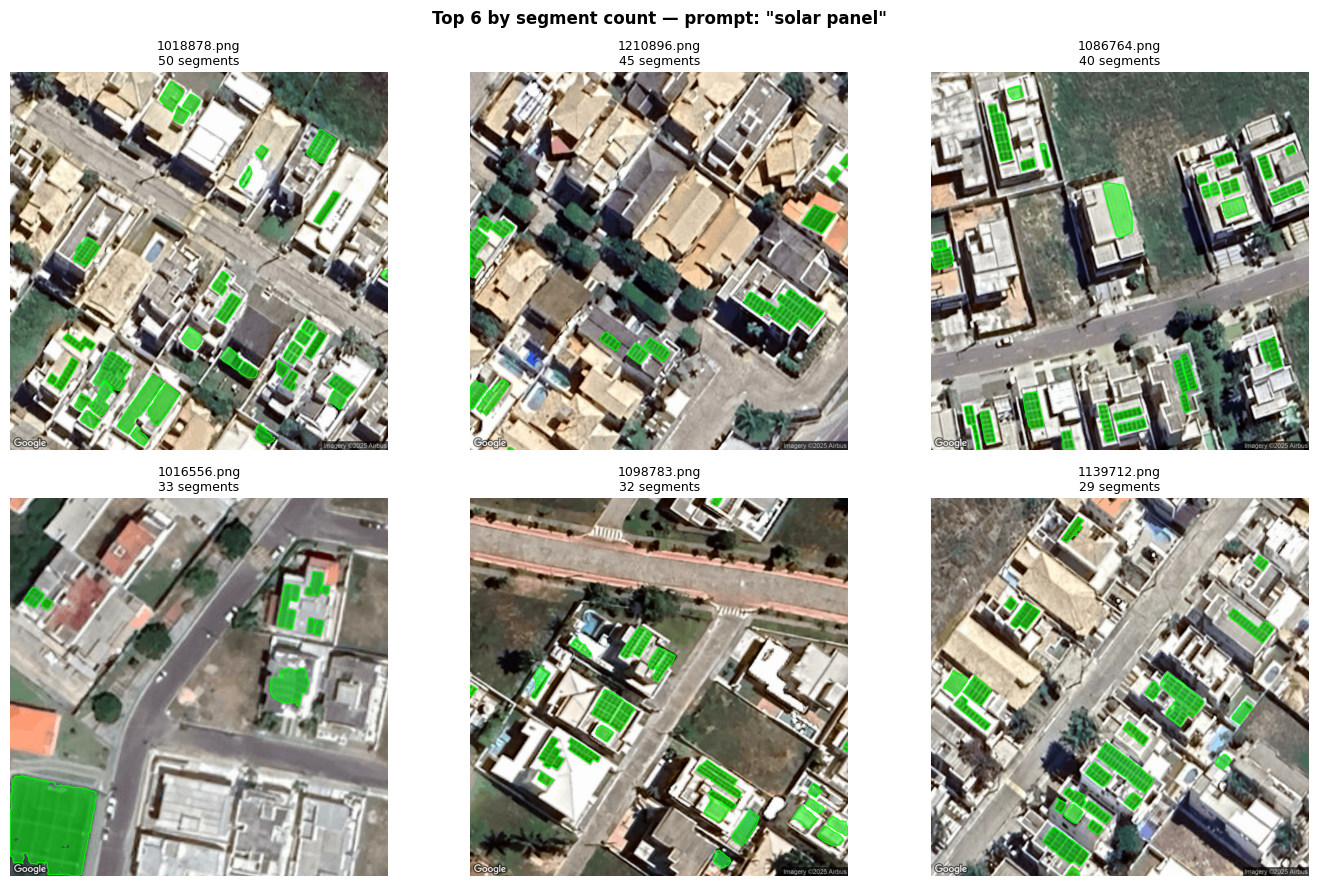


=== Evaluation metrics (labeled subset) ===
            Metric  Value
         precision 0.8197
            recall 0.4543
                f1 0.5846
    pixel_accuracy 0.9597
          mean_iou 0.4147
     n_eval_images     15
n_inference_images     52


In [9]:
def mask_to_numpy(mask, h, w):
    if isinstance(mask, torch.Tensor):
        mask_np = mask.cpu().numpy()
    else:
        mask_np = np.asarray(mask)
    if mask_np.shape != (h, w):
        mask_np = cv2.resize(mask_np.astype(np.float32), (w, h))
    return mask_np


def visualize_segmentation(img_path, masks, ax, title=None):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    overlay = img_rgb.copy()

    if masks is not None and masks.data is not None and len(masks.data) > 0:
        combined = np.zeros((h, w), dtype=np.uint8)
        for mask in masks.data:
            mask_np = mask_to_numpy(mask, h, w)
            combined = np.maximum(combined, (mask_np > CONFIG["MASK_THRESHOLD"]).astype(np.uint8))
        overlay[combined > 0] = [0, 255, 0]
        img_rgb = cv2.addWeighted(img_rgb, 0.5, overlay, 0.5, 0)
        contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(img_rgb, contours, -1, (0, 255, 0), 2)

    ax.imshow(img_rgb)
    ax.axis("off")
    n = len(masks.data) if masks is not None and masks.data is not None else 0
    ax.set_title(title or f"{Path(img_path).name}\n{n} segments", fontsize=9)


if SAM3_AVAILABLE and inference_results:
    df_inf = pd.DataFrame([{"image": r["image"], "num_segments": r["num_segments"]} for r in inference_results])
    top6 = df_inf.nlargest(6, "num_segments")["image"].tolist()
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    for ax, name in zip(axes.flatten(), top6):
        row = next(r for r in inference_results if r["image"] == name)
        visualize_segmentation(row["path"], row["masks"], ax)
    plt.suptitle(f'Top 6 by segment count — prompt: "{CONFIG["TEXT_PROMPT"]}"', fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    summary_display = pd.DataFrame([{
        "Metric": k,
        "Value": f"{metrics_summary[k]:.4f}" if isinstance(metrics_summary[k], float) else metrics_summary[k],
    } for k in ("precision", "recall", "f1", "pixel_accuracy", "mean_iou", "n_eval_images", "n_inference_images")])
    print("\n=== Evaluation metrics (labeled subset) ===")
    print(summary_display.to_string(index=False))
else:
    print("No inference results to visualize.")


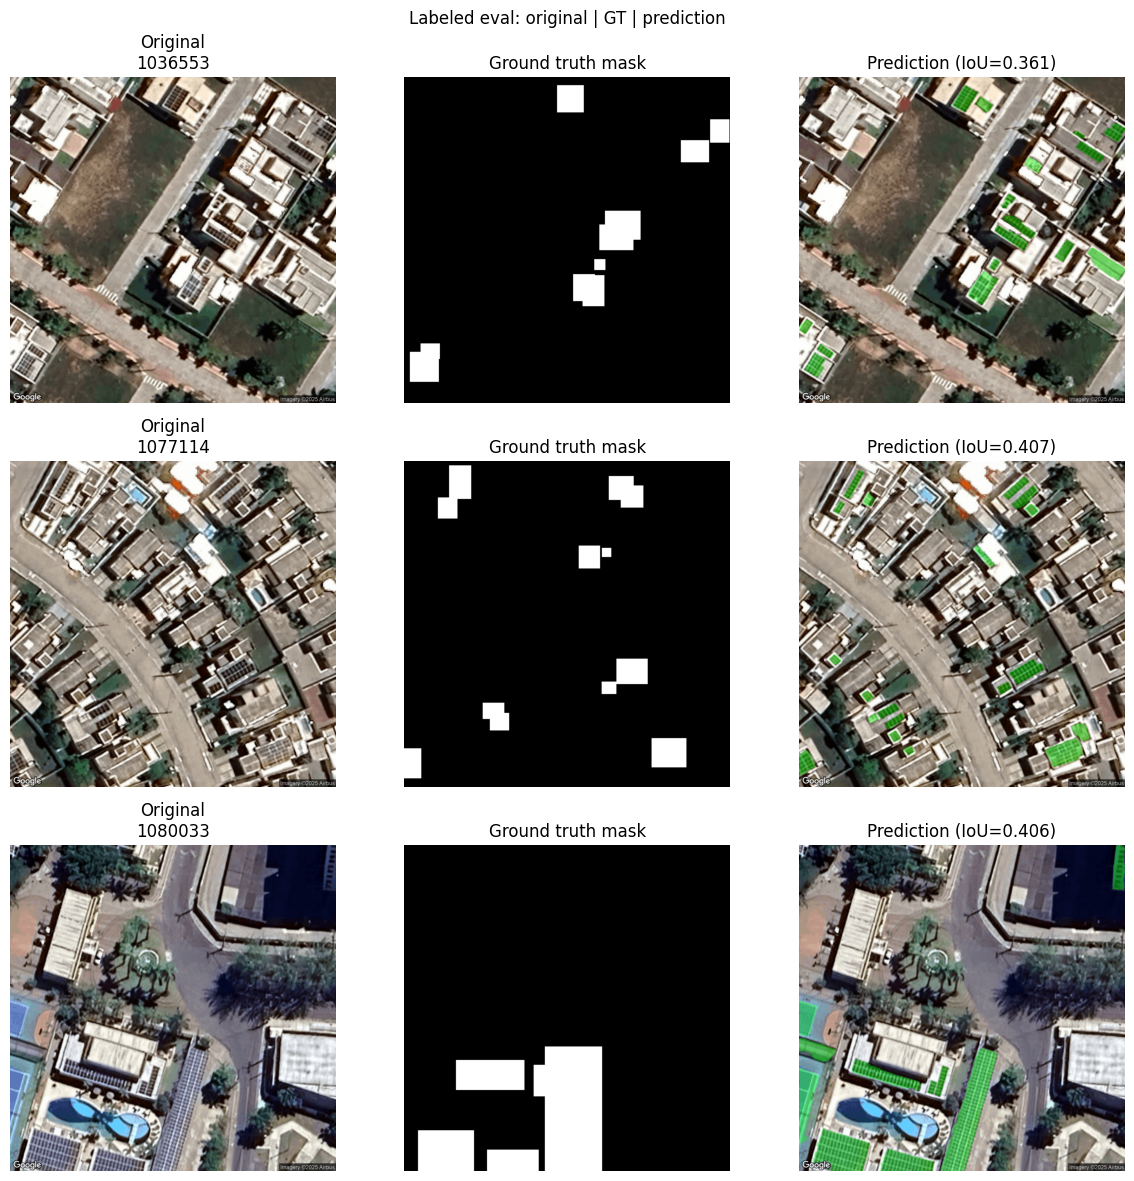


=== Detected area per image (all inference set) ===
Assumptions: 0.3 m/pixel, 0.15 kW/m²
          image  num_segments  area_pixels  area_m2  coverage_pct  est_power_kw
    1132186.png            10       157176 14145.84      9.593262     2121.8760
    1080033.png            13       132111 11889.99      8.063416     1783.4985
    1016556.png            33       107153  9643.77      6.540100     1446.5655
    1018878.png            50       107018  9631.62      6.531860     1444.7430
    1133618.png            11       104310  9387.90      6.366577     1408.1850
    1234633.png            24       102909  9261.81      6.281067     1389.2715
    1139712.png            29        88260  7943.40      5.386963     1191.5100
    1086764.png            40        85404  7686.36      5.212646     1152.9540
    1098783.png            32        74826  6734.34      4.567017     1010.1510
    1131456.png            22        62247  5602.23      3.799255      840.3345
    1102679.png            12 

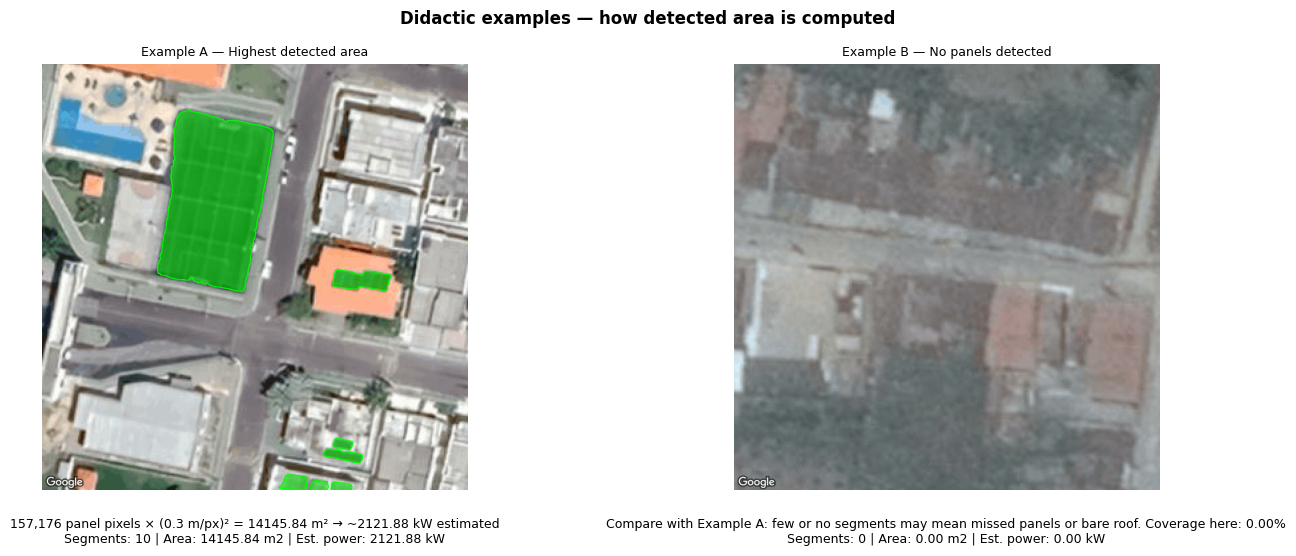

PIPELINE SUMMARY (SAM 3)
Text prompt: solar panel
Device: cuda
Inference images: 52
Images with detections: 35 (67.3%)
Eval images (labeled): 15
Precision: 0.8197 | Recall: 0.4543 | F1: 0.5846
Results: results\sam3_pipeline
MLflow run: 0e7e755864af456da0e87a57ba93a79b
MLflow run ended.


In [11]:
n_show = min(3, len(eval_items))
if SAM3_AVAILABLE and n_show > 0:
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
    if n_show == 1:
        axes = np.expand_dims(axes, 0)
    for i, (item, pred_row) in enumerate(zip(eval_items[:n_show], eval_inference_results[:n_show])):
        img = cv2.cvtColor(cv2.imread(str(item["path"])), cv2.COLOR_BGR2RGB)
        gt = yolo_boxes_to_mask(item["label_path"], pred_row["width"], pred_row["height"])
        pr = pred_row["pred_mask"]
        overlay = img.copy()
        overlay[pr > 0] = [0, 255, 0]
        blend = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original\n{item['stem']}")
        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground truth mask")
        axes[i, 2].imshow(blend)
        axes[i, 2].set_title(f"Prediction (IoU={per_image_rows[i]['iou']:.3f})")
        for j in range(3):
            axes[i, j].axis("off")
    plt.suptitle("Labeled eval: original | GT | prediction", fontsize=12)
    plt.tight_layout()
    plt.show()

if SAM3_AVAILABLE and inference_results:
    mpp = CONFIG["METERS_PER_PIXEL"]
    power_per_sqm = CONFIG["POWER_KW_PER_SQM"]

    df_area = pd.DataFrame([
        {
            "image": r["image"],
            "num_segments": r["num_segments"],
            "area_pixels": r["area_pixels"],
            "area_m2": r["area_pixels"] * (mpp ** 2),
            "coverage_pct": r["coverage_pct"],
            "est_power_kw": r["area_pixels"] * (mpp ** 2) * power_per_sqm,
        }
        for r in inference_results
    ]).sort_values("area_m2", ascending=False)

    df_area.to_csv(out / "detected_area_table.csv", index=False, encoding="utf-8-sig")
    mlflow.log_artifact(str(out / "detected_area_table.csv"))

    print("\n=== Detected area per image (all inference set) ===")
    print(f"Assumptions: {mpp} m/pixel, {power_per_sqm} kW/m²")
    display_cols = ["image", "num_segments", "area_pixels", "area_m2", "coverage_pct", "est_power_kw"]
    print(df_area[display_cols].to_string(index=False))

    def _result_by_image(name):
        return next(r for r in inference_results if r["image"] == name)

    row_high = df_area.iloc[0]
    ex_high = _result_by_image(row_high["image"])

    zero_panel = df_area[df_area["num_segments"] == 0]
    if len(zero_panel) > 0:
        row_low = zero_panel.iloc[0]
        ex_low_label = "Example B — No panels detected"
    else:
        row_low = df_area.iloc[-1]
        ex_low_label = "Example B — Lowest detected area"
    ex_low = _result_by_image(row_low["image"])

    didactic_examples = [
        {
            "label": "Example A — Highest detected area",
            "row": ex_high,
            "stats": row_high,
            "note": (
                f"{int(row_high['area_pixels']):,} panel pixels × ({mpp} m/px)² "
                f"= {row_high['area_m2']:.2f} m² → ~{row_high['est_power_kw']:.2f} kW estimated"
            ),
        },
        {
            "label": ex_low_label,
            "row": ex_low,
            "stats": row_low,
            "note": (
                "Compare with Example A: few or no segments may mean missed panels or bare roof. "
                f"Coverage here: {row_low['coverage_pct']:.2f}%"
            ),
        },
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, ex in zip(axes, didactic_examples):
        visualize_segmentation(ex["row"]["path"], ex["row"]["masks"], ax, title=ex["label"])
        s = ex["stats"]
        ax.text(
            0.5, -0.12,
            f"{ex['note']}\nSegments: {int(s['num_segments'])} | Area: {s['area_m2']:.2f} m2 | Est. power: {s['est_power_kw']:.2f} kW",
            transform=ax.transAxes, ha="center", fontsize=9, wrap=True,
        )
    plt.suptitle("Didactic examples — how detected area is computed", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)
    plt.show()

    images_with_panels = sum(1 for r in inference_results if r["num_segments"] > 0)
    print("=" * 60)
    print("PIPELINE SUMMARY (SAM 3)")
    print("=" * 60)
    print(f"Text prompt: {CONFIG['TEXT_PROMPT']}")
    print(f"Device: {CONFIG['DEVICE']}")
    print(f"Inference images: {len(inference_results)}")
    print(f"Images with detections: {images_with_panels} ({100 * images_with_panels / max(len(inference_results), 1):.1f}%)")
    print(f"Eval images (labeled): {len(eval_items)}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"Results: {out}")
    print(f"MLflow run: {mlflow_run.info.run_id}")
    print("=" * 60)

if mlflow.active_run() is not None:
    mlflow.end_run()
    print("MLflow run ended.")
else:
    print("No active MLflow run to end.")
